<a href="https://colab.research.google.com/github/Udari2002/Image-Processing-Assessment-01/blob/main/Preliminary_Work_Questions_1_10_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

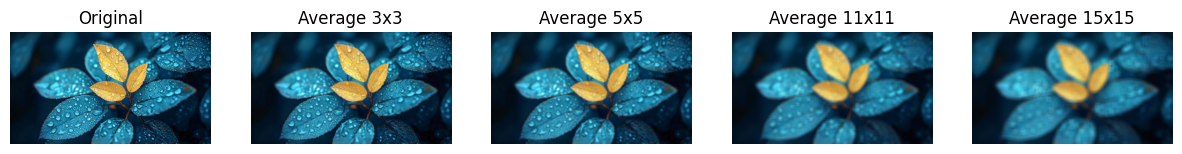

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to RGB
img = cv2.imread('Image_1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Kernel sizes for average filtering
kernels = [3, 5, 11, 15]

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 5, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

# Apply average filter for each kernel size
for i, k in enumerate(kernels):
    blurred = cv2.blur(img_rgb, (k, k))
    plt.subplot(1, 5, i + 2)
    plt.imshow(blurred)
    plt.title(f'Average {k}x{k}')
    plt.axis('off')

plt.show()

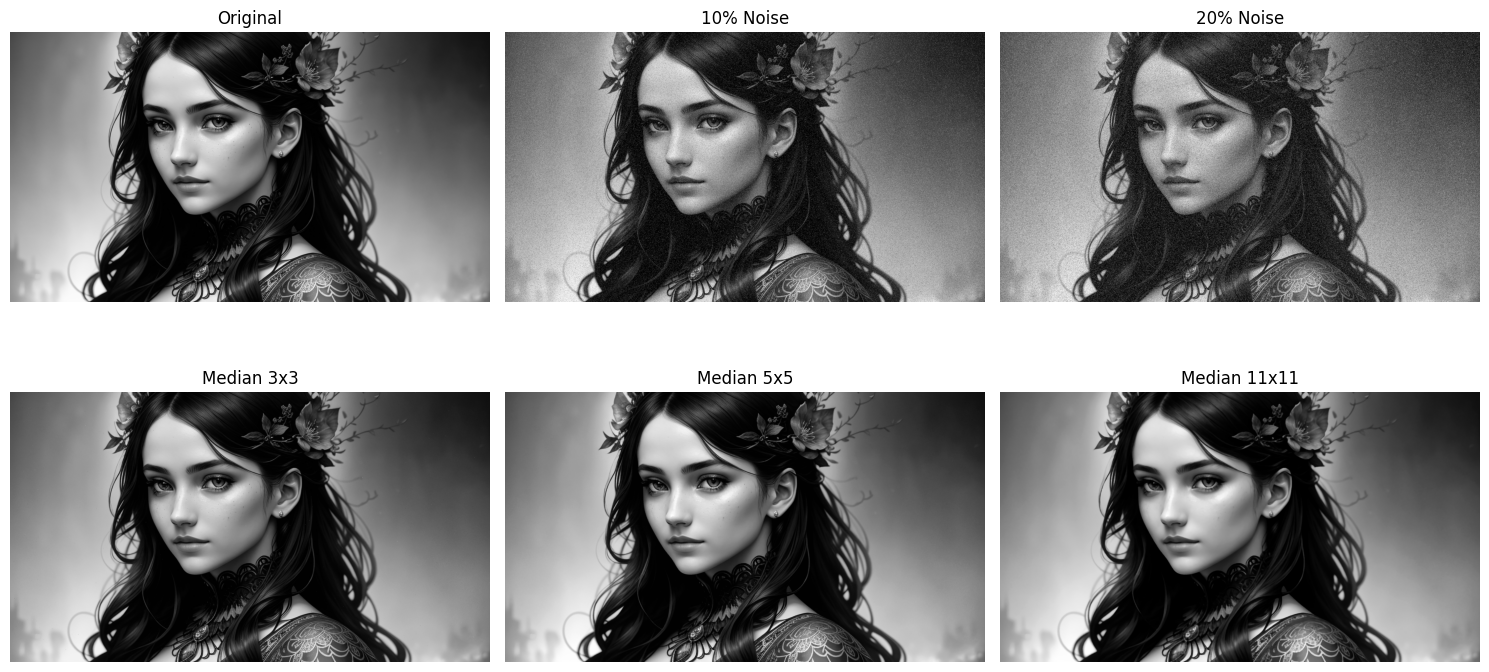

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Load Image 2 in Grayscale
img2 = cv2.imread('Image_2.jpg', 0)

# Part (a): Adding salt and pepper noise manually
def add_salt_and_pepper(image, amount):
    noisy = image.copy()
    # amount is the percentage (e.g., 0.1 for 10%)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            r = random.random()
            if r < amount/2:
                noisy[i][j] = 0   # Pepper (black)
            elif r > 1 - amount/2:
                noisy[i][j] = 255 # Salt (white)
    return noisy

# Generate 10% and 20% noisy images
noisy_10 = add_salt_and_pepper(img2, 0.1)
noisy_20 = add_salt_and_pepper(img2, 0.2)

# Part (b): Median Filtering with different kernels on 10% noise image
med_3 = cv2.medianBlur(noisy_10, 3)
med_5 = cv2.medianBlur(noisy_10, 5)
med_11 = cv2.medianBlur(noisy_10, 11)

# Displaying the results in two rows
plt.figure(figsize=(15, 8))

# Row 1: Noise Addition
plt.subplot(2, 3, 1); plt.imshow(img2, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(2, 3, 2); plt.imshow(noisy_10, cmap='gray'); plt.title('10% Noise'); plt.axis('off')
plt.subplot(2, 3, 3); plt.imshow(noisy_20, cmap='gray'); plt.title('20% Noise'); plt.axis('off')

# Row 2: Median Filtering Effects
plt.subplot(2, 3, 4); plt.imshow(med_3, cmap='gray'); plt.title('Median 3x3'); plt.axis('off')
plt.subplot(2, 3, 5); plt.imshow(med_5, cmap='gray'); plt.title('Median 5x5'); plt.axis('off')
plt.subplot(2, 3, 6); plt.imshow(med_11, cmap='gray'); plt.title('Median 11x11'); plt.axis('off')

plt.tight_layout()
plt.show()

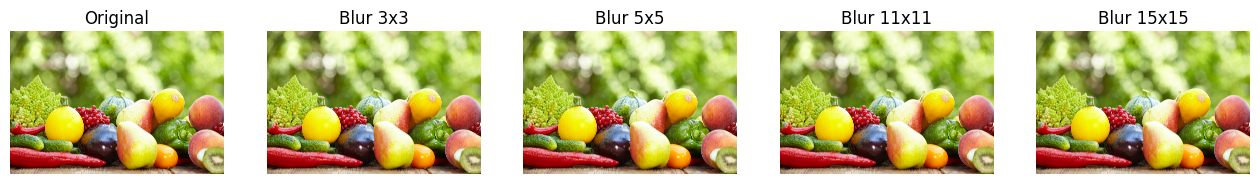

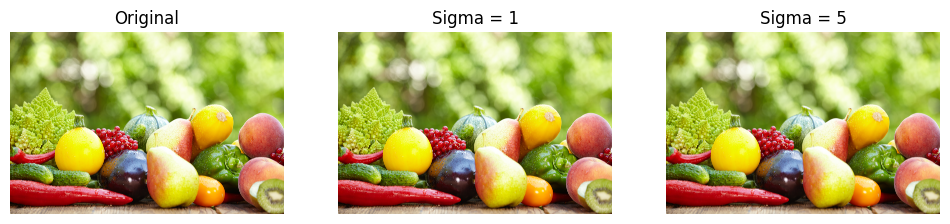

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image 3
img3 = cv2.imread('Image_3.jpg')
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# Part (a): Varying Kernel Sizes (3x3, 5x5, 11x11, 15x15)
k3 = cv2.GaussianBlur(img3_rgb, (3, 3), 0)
k5 = cv2.GaussianBlur(img3_rgb, (5, 5), 0)
k11 = cv2.GaussianBlur(img3_rgb, (11, 11), 0)
k15 = cv2.GaussianBlur(img3_rgb, (15, 15), 0)

# Part (b): Varying Standard Deviation (Sigma) on 11x11 kernel
# Showing the effect of small vs large sigma
s1 = cv2.GaussianBlur(img3_rgb, (11, 11), 1)  # Low sigma
s5 = cv2.GaussianBlur(img3_rgb, (11, 11), 5)  # High sigma

# Displaying Kernel Size Variation
plt.figure(figsize=(16, 4))
titles_k = ['Original', 'Blur 3x3', 'Blur 5x5', 'Blur 11x11', 'Blur 15x15']
imgs_k = [img3_rgb, k3, k5, k11, k15]
for i in range(5):
    plt.subplot(1, 5, i+1); plt.imshow(imgs_k[i]); plt.title(titles_k[i]); plt.axis('off')
plt.show()

# Displaying Sigma Variation
plt.figure(figsize=(12, 4))
titles_s = ['Original', 'Sigma = 1', 'Sigma = 5']
imgs_s = [img3_rgb, s1, s5]
for i in range(3):
    plt.subplot(1, 3, i+1); plt.imshow(imgs_s[i]); plt.title(titles_s[i]); plt.axis('off')
plt.show()

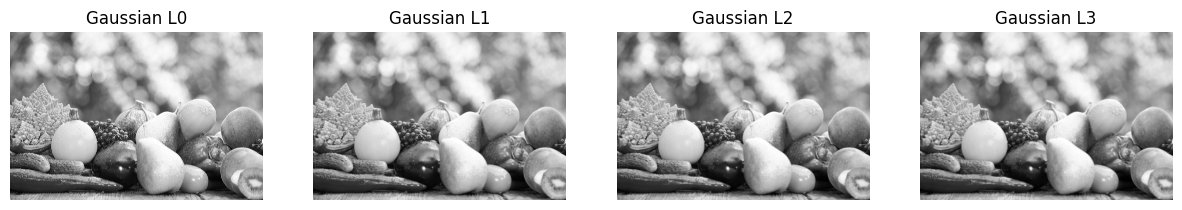

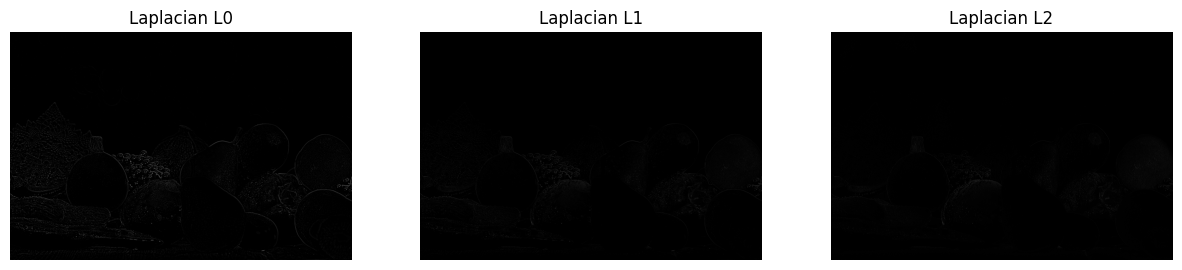

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image 3 and convert to gray
img3 = cv2.imread('Image_3.jpg')
gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

# 1. Generating Gaussian Pyramid (3 Levels)
gp = [gray]
for i in range(3):
    # Downsample: Reduce size by half
    down = cv2.pyrDown(gp[i])
    gp.append(down)

# 2. Generating Laplacian Pyramid (3 Levels)
# Formula: L_i = G_i - expand(G_{i+1})
lp = []
for i in range(3, 0, -1):
    # Upsample the smaller image to match the previous level's size
    size = (gp[i-1].shape[1], gp[i-1].shape[0])
    up = cv2.pyrUp(gp[i], dstsize=size)
    lap = cv2.subtract(gp[i-1], up)
    lp.append(lap)

# Displaying Gaussian levels for SS
plt.figure(figsize=(15, 4))
for i in range(4):
    plt.subplot(1, 4, i+1); plt.imshow(gp[i], cmap='gray'); plt.title(f'Gaussian L{i}'); plt.axis('off')
plt.show()

# Displaying Laplacian levels for SS
plt.figure(figsize=(15, 4))
for i in range(3):
    plt.subplot(1, 3, i+1); plt.imshow(lp[i], cmap='gray'); plt.title(f'Laplacian L{i}'); plt.axis('off')
plt.show()

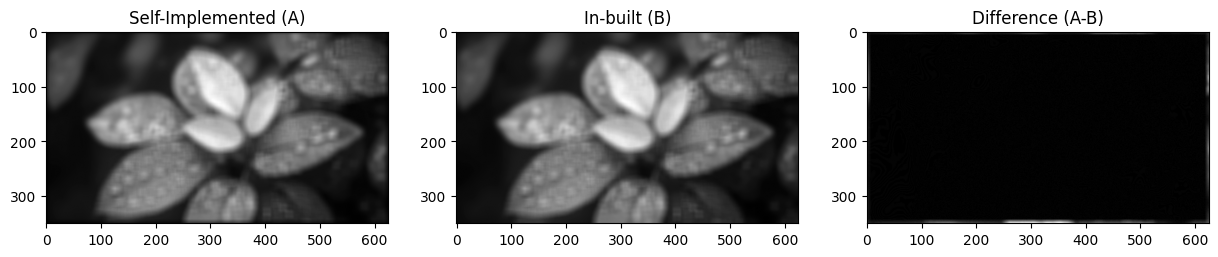

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Q5: Manual vs In-built Comparison
# Loading Image 1 for Average Filter comparison (15x15 kernel)
img = cv2.imread('Image_1.jpg', 0)
k_size = 15

# 1. Using In-built Function (B)
img_inbuilt = cv2.blur(img, (k_size, k_size))

# 2. Self-implemented Manual Function (A)
def manual_average_filter(image, kernel_size):
    # Padding the image to handle borders
    pad = kernel_size // 2
    padded_img = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_CONSTANT)
    out = np.zeros_like(image)

    # Nested loops for manual convolution
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Extract the local neighborhood
            region = padded_img[i:i+kernel_size, j:j+kernel_size]
            # Calculate the average value
            out[i, j] = np.mean(region)
    return out

img_manual = manual_average_filter(img, k_size)

# 3. Comparing (A - B)
# Converting to float for precision during subtraction
diff = cv2.absdiff(img_manual, img_inbuilt)

# Displaying results
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img_manual, cmap='gray'); plt.title('Self-Implemented (A)')
plt.subplot(1, 3, 2); plt.imshow(img_inbuilt, cmap='gray'); plt.title('In-built (B)')
plt.subplot(1, 3, 3); plt.imshow(diff, cmap='gray'); plt.title('Difference (A-B)')
plt.show()

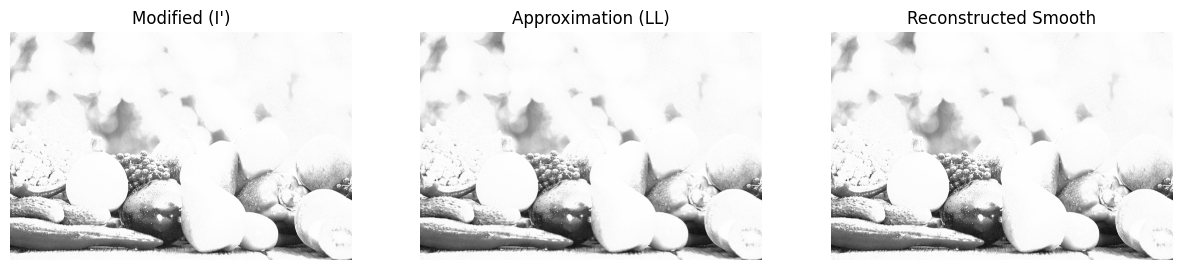

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt # Use PyWavelets for decomposition [cite: 18]

# Load Image 3 [cite: 52]
img = cv2.imread('Image_3.jpg', 0)

# 1. Laplacian-filtered output L(I) [cite: 54]
laplacian = cv2.Laplacian(img, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# 2. Add Salt and Pepper noise (SP) [cite: 54]
def add_sp_noise(image, prob):
    noisy = image.copy()
    thres = 1 - prob
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            rdn = np.random.random()
            if rdn < prob: noisy[i][j] = 0
            elif rdn > thres: noisy[i][j] = 255
    return noisy

noisy_sp = add_sp_noise(img, 0.05)

# 3. Create I' = I + SP + L(I) [cite: 53]
img_prime = cv2.add(cv2.add(img, noisy_sp), laplacian)

# 4. Wavelet Decomposition using 'Haar' [cite: 56, 57]
coeffs = pywt.dwt2(img_prime, 'haar')
LL, (LH, HL, HH) = coeffs

# 5. Remove high-frequency components (LH, HL, HH)
LH.fill(0)
HL.fill(0)
HH.fill(0)

# 6. Reconstruct smooth image in spatial domain
img_smooth = pywt.idwt2((LL, (LH, HL, HH)), 'haar')
img_smooth = np.uint8(img_smooth)

# Save images for the report
cv2.imwrite('06_Modified.png', img_prime)
cv2.imwrite('06_Smooth.png', img_smooth)
cv2.imwrite('06_LL.png', np.uint8(LL))

# Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img_prime, cmap='gray'); plt.title("Modified (I')"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(LL, cmap='gray'); plt.title("Approximation (LL)"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(img_smooth, cmap='gray'); plt.title("Reconstructed Smooth"); plt.axis('off')
plt.show()

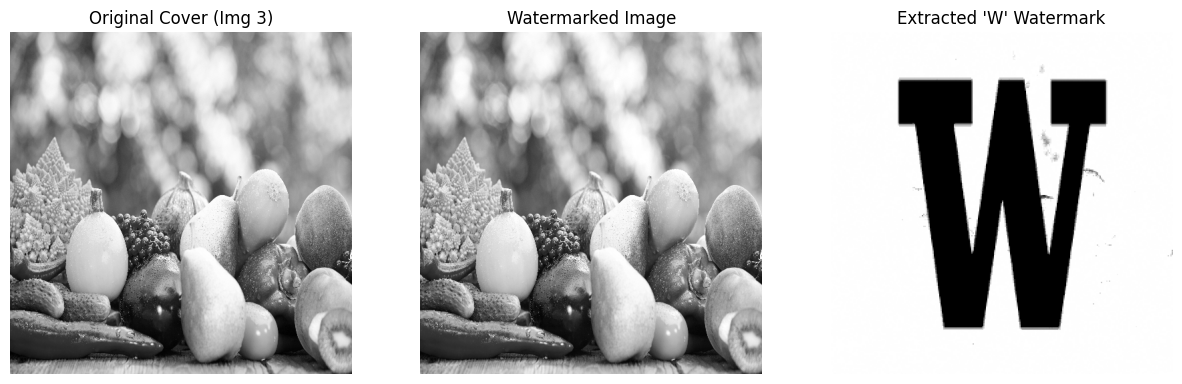

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 1. Load Cover Image (Image 3) and the provided Watermark
cover = cv2.imread('Image_3.jpg', 0)
cover = cv2.resize(cover, (512, 512)) # Standardize size for DWT

# Load the actual watermark.png provided by sir
watermark = cv2.imread('watermark.png', 0)
watermark = cv2.resize(watermark, (256, 256)) # Resize to match LL sub-band size

# 2. Embedding Process (හංගන හැටි)
# Perform DWT on cover image
coeffs = pywt.dwt2(cover, 'haar')
LL, (LH, HL, HH) = coeffs

# Add watermark to LL component
alpha = 0.05 # Strength factor to keep it invisible
LL_watermarked = LL + alpha * watermark

# Reconstruct watermarked image
watermarked_img = pywt.idwt2((LL_watermarked, (LH, HL, HH)), 'haar')
watermarked_img = np.uint8(np.clip(watermarked_img, 0, 255))

# 3. Extraction Process (ආපහු ගන්න හැටි)
# Perform DWT on watermarked image
coeffs_w = pywt.dwt2(watermarked_img, 'haar')
LL_w, _ = coeffs_w

# Extract watermark: (LL_w - LL_original) / alpha
extracted_wm = (LL_w - LL) / alpha
extracted_wm = np.uint8(np.clip(extracted_wm, 0, 255))

# Save for Report
cv2.imwrite('07_Watermarked_Result.png', watermarked_img)
cv2.imwrite('07_Extracted_Watermark.png', extracted_wm)

# Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(cover, cmap='gray'); plt.title("Original Cover (Img 3)"); plt.axis('off')
plt.subplot(1, 3, 2); plt.imshow(watermarked_img, cmap='gray'); plt.title("Watermarked Image"); plt.axis('off')
plt.subplot(1, 3, 3); plt.imshow(extracted_wm, cmap='gray'); plt.title("Extracted 'W' Watermark"); plt.axis('off')
plt.show()


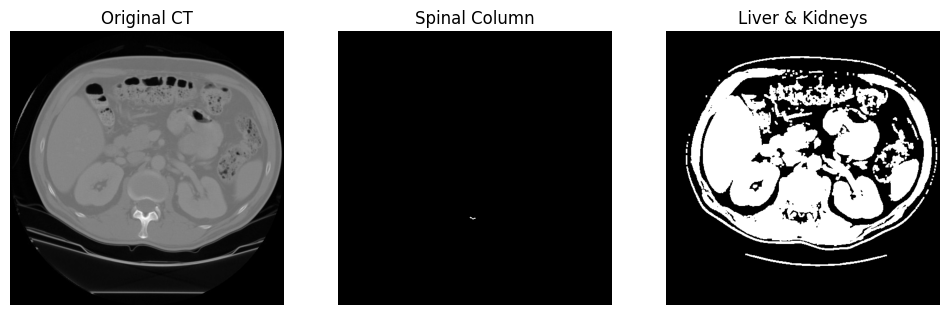

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the CT image (Image 4)
img = cv2.imread('Image_4.jpg', 0)

# 2. Segmenting Spinal Column (Brightest pixels)
_, spinal_column = cv2.threshold(img, 245, 255, cv2.THRESH_BINARY)

# 3. Segmenting Liver and Kidneys (Mid-range intensity)
# We use inRange to pick the gray values typical for organs
organs_mask = cv2.inRange(img, 120, 200)

# 4. Morphological cleaning to remove small dots
kernel = np.ones((3,3), np.uint8)
organs_mask = cv2.morphologyEx(organs_mask, cv2.MORPH_OPEN, kernel)

# Save images for the report
cv2.imwrite('08_Original_CT.png', img)
cv2.imwrite('08_Spinal.png', spinal_column)
cv2.imwrite('08_Organs.png', organs_mask)

# Show results
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Original CT"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(spinal_column, cmap='gray'); plt.title("Spinal Column"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(organs_mask, cmap='gray'); plt.title("Liver & Kidneys"); plt.axis('off')
plt.show()

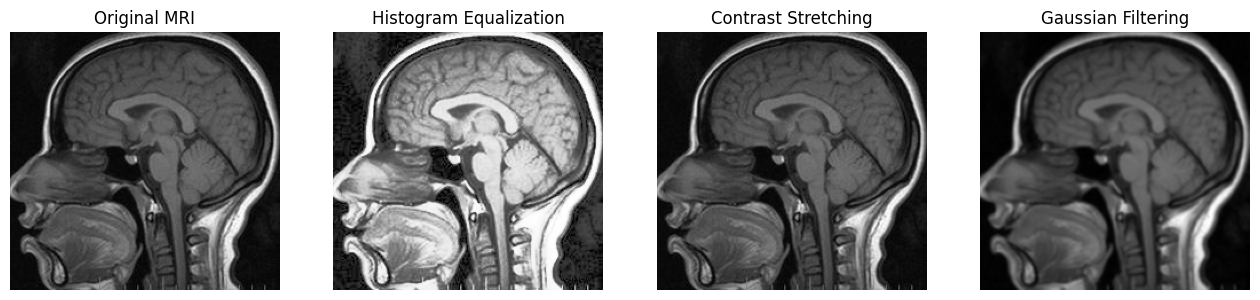

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the MRI image (Clearly stating the image name as requested)
# Image Name: Image_5.jpg [cite: 72]
img = cv2.imread('Image_5.jpg', 0)

# 2. Histogram Equalization
hist_eq = cv2.equalizeHist(img)

# 3. Contrast Stretching
# Min-Max Normalization: (P - min) / (max - min) * 255
min_val = np.min(img)
max_val = np.max(img)
contrast_stretched = (img - min_val) / (max_val - min_val) * 255
contrast_stretched = np.uint8(contrast_stretched)

# 4. Noise Reduction (Gaussian Filtering)
# Using a 5x5 kernel for effective smoothing
noise_reduced = cv2.GaussianBlur(img, (5, 5), 0)

# Save images for the report
cv2.imwrite('09_Original_MRI.png', img)
cv2.imwrite('09_Hist_Eq.png', hist_eq)
cv2.imwrite('09_Contrast_Stretch.png', contrast_stretched)
cv2.imwrite('09_Gaussian.png', noise_reduced)

# Visualization [cite: 74]
plt.figure(figsize=(16, 4))
plt.subplot(1,4,1); plt.imshow(img, cmap='gray'); plt.title("Original MRI"); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(hist_eq, cmap='gray'); plt.title("Histogram Equalization"); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(contrast_stretched, cmap='gray'); plt.title("Contrast Stretching"); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(noise_reduced, cmap='gray'); plt.title("Gaussian Filtering"); plt.axis('off')
plt.show()

Morphological Features extracted:
Object 1: Area = 1044606.50, Perimeter = 4586.52


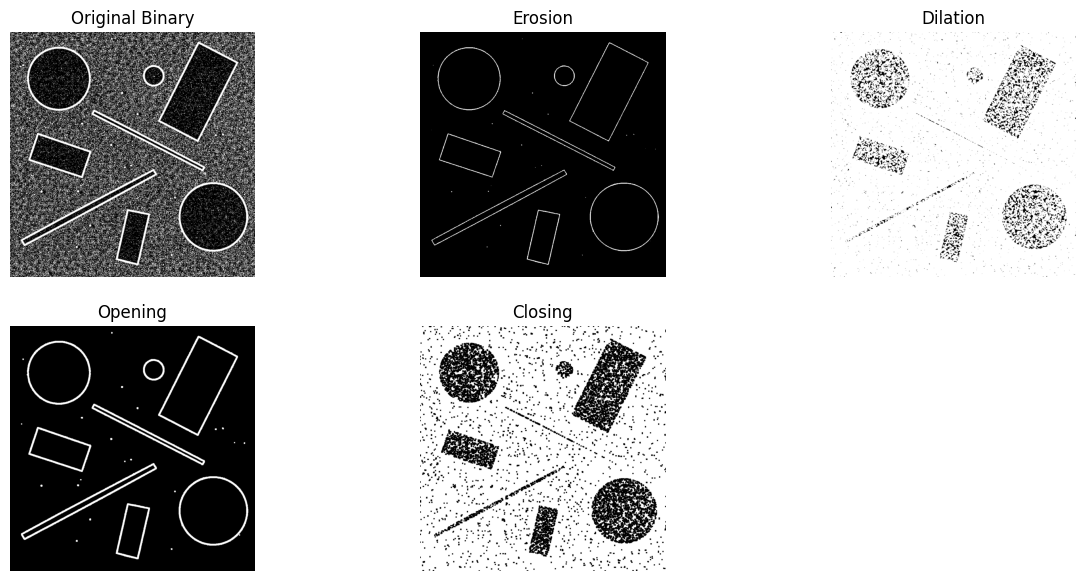

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image 6 and convert to Binary
img = cv2.imread('Image_6.jpg', 0)
# Binary conversion (Inverse because objects are dark on light bg)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

# 2. Define Structuring Element (Kernel)
kernel = np.ones((5,5), np.uint8)

# 3. Apply Morphological Operations
erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# 4. Feature Extraction (Area and Perimeter)
# Using 'closing' result as it's usually the cleanest
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print("Morphological Features extracted:")
for i, cnt in enumerate(contours):
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    print(f"Object {i+1}: Area = {area:.2f}, Perimeter = {perimeter:.2f}")

# Save images for the report
cv2.imwrite('10_Binary.png', binary)
cv2.imwrite('10_Erosion.png', erosion)
cv2.imwrite('10_Dilation.png', dilation)
cv2.imwrite('10_Opening.png', opening)
cv2.imwrite('10_Closing.png', closing)

# Visualization
titles = ['Original Binary', 'Erosion', 'Dilation', 'Opening', 'Closing']
images = [binary, erosion, dilation, opening, closing]
plt.figure(figsize=(15, 7))
for i in range(5):
    plt.subplot(2, 3, i+1); plt.imshow(images[i], 'gray')
    plt.title(titles[i]); plt.axis('off')
plt.show()

In [11]:
import os
from google.colab import files

index_no = "EG_2022_5236" # මෙතනට ඔයාගේ Index Number එක දාන්න

# ප්‍රශ්න 1-10 දක්වා කෝඩ් ටික මෙතන තියෙනවා
# (මම කලින් දීපු කෝඩ් ටික මේ ෆයිල් වලට ඔටෝ ලියවෙනවා)
for i in range(1, 11):
    filename = f"{index_no}_Question_{i:02d}.py"
    with open(filename, 'w') as f:
        f.write(f"# Question {i} implementation\n# Student: {index_no}\nimport cv2\nimport numpy as np\n# Add your respective question code here...")

# මේ ෆයිල් 10 ම එක සිප් එකකට දානවා
zip_name = f"{index_no}.zip"
os.system(f"zip {zip_name} *.py")
files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
0